In [1]:
subset = True
n_fraction = 0.2

short_run = True

In [2]:
import os
from typing import Optional, Dict, List, Literal
import copy

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.metrics import normalized_mutual_info_score

import torch
from geomloss import SamplesLoss
import torch.nn as nn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [3]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import discriminator_weight_curve, embed_tf_activity, get_alignment_score

sys.path.insert(1, '../.')
from Kang_utils import get_prediction, rev_stim

In [4]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 42
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
test_splits = pd.read_csv('test_splits.csv', index_col = 0)
fold = 2
seed = test_splits[test_splits.fold == fold]['seed'].tolist()[0]

In [6]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Create a novel train-test split:

In [7]:
def ood_split(tf_adata, 
             train_frac: float, 
              stim_col: str = 'stim', 
              context_col: str = 'seurat_annotations', 
              context_bins: Optional[pd.DataFrame] = None, 
              context_bins_frac: float = 1, 
             max_iter: int = 1000, 
             seed: int = 888, 
             deviation_thresh: float = 0.025, 
             include_train_cond: Optional[Dict[str, List]] = None):
    """Generate an OOD train test split, where both the condition data and the single-cells have approximately
    the specified split.
    
    Rules: 
    1. cell split and condition split is similar (conditions is exactly the split, 
    cells is approximate by deviation_thresh)
    2. Each component (condition_cols) of the condition is seen atleast once in the training
    3. Each of the stimulation column is seen atleast once in the test
    4. The test context (cell type) needs to contain atleast one from context_frac of the total context_bins 

    Parameters
    ----------
    tf_adata : 
        AnnData object of TF activity
    train_frac : float
        the fraction of the data going to training
    stim_col : List[str]
        the metadata column defining the stimulation condition
    context_col: str
        the metadata column of the context, together with stim col defines the OOD split
    context_bins: Optional[pd.DataFrame]
        binning of the context categories, by default None
    context_bins_frac: float
        the number of bins that should be included in the test data from the context bins
    max_iter : int, optional
        total iterations to try to identify a suitable split, by default 1000
    seed : int, optional
        random state variable, by default 888
    deviation_thresh : float, optional
        extent to which to allow the single-cell split to deviate from the specified `train_frac split`, by default 0.025
    include_train_cond : Optional[Dict[str, List]]
        a dictionary with keys for each of stim_col and context_col and keys as a list that represents a subset
        of values in that column that must be included in the training set. 
    """
    test_frac = 1 - train_frac

    condition_cols = [stim_col, context_col]
    condition_combs = tf_adata.obs[condition_cols].apply(lambda row: '^'.join(row.astype(str)), axis=1)
    unique_conditions = condition_combs.drop_duplicates(keep = 'first', inplace = False).tolist()

    # define the conditions for stopping
    train_frac_deviation = np.inf
    zero_shot_bool = False

    test_stim = False
    n_stims = tf_adata.obs['stim'].nunique()

    if context_bins is not None:
        if context_bins_frac > 1 or context_bins_frac < 0:
            raise ValueError('The fraction must be between 0 and 1')
        n_contexts = np.floor(context_bins_frac*context_bins.nunique())
        context_present = False
    else:
        context_present = True

    if include_train_cond is not None:
        if sorted(set(include_train_cond).intersection(condition_cols)) != sorted(condition_cols):
            raise ValueError('Keys for `include_train_cond` must be the same as `condition_cols`')
        for cond, cond_vals in include_train_cond.items():
            if not set(cond_vals).issubset(tf_adata.obs[cond].tolist()):
                raise ValueError('The conditions to include in training for ' + cond + ' are not present in the metadata.')
        ict_bool = False
    else:
        ict_bool = True

    counter = 0
    while (train_frac_deviation > deviation_thresh or not zero_shot_bool or not ict_bool or not test_stim or not context_present) and (counter < max_iter):
        # ood at categorical level
        train_cond, test_cond = train_test_split(unique_conditions, test_size = test_frac, random_state = seed + counter, shuffle = True)
        train_cells = condition_combs[condition_combs.isin(train_cond)].index.tolist()
        test_cells = condition_combs[condition_combs.isin(test_cond)].index.tolist()

        train_frac_actual = len(train_cells)/tf_adata.shape[0]
        train_frac_deviation = abs(train_frac_actual - train_frac)

        # ensure that all individual conditions are seen atleast once (it's the combination of conditions that's unique)
        train_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            train_cond_map[cond] = {tc.split('^')[idx] for tc in train_cond}

        test_cond_map = {}
        for idx, cond in enumerate(condition_cols):
            test_cond_map[cond] = {tc.split('^')[idx] for tc in test_cond}

        zero_shots = [len(test_cond_map[cond].difference(train_cond_map[cond])) for cond in condition_cols]    
        zero_shot_bool = all(value == 0 for value in zero_shots)

        test_stim = (len(test_cond_map['stim']) == n_stims)


        if context_bins is not None:
            context_present = context_bins.loc[list(test_cond_map[context_col])].nunique() >= n_contexts

        if include_train_cond is not None:
            ict_conds = [len(include_train_cond[cond].difference(cond_vals)) for cond, cond_vals in train_cond_map.items()]
            ict_bool = any(value == 0 for value in ict_conds)

        counter += 1

    if counter < max_iter:
        return train_cells, test_cells, train_cond, test_cond
    else:
        return None, None, None, None

In [8]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table = contingency_table.T.sort_values(by = 'Total').T
bins = pd.qcut(contingency_table.T.Total, q = 4, labels = False)

In [9]:
train_frac, test_frac = 0.8, 0.2
condition_cols = ['stim', 'seurat_annotations']
train_cells, test_cells, train_cond, test_cond = ood_split(tf_adata,
                                                                   train_frac = 0.8,
                                                                   stim_col = condition_cols[0], 
                                                                   context_col = condition_cols[1], 
                                                                   context_bins = bins, 
                                                                   context_bins_frac = 1, 
                                                                   max_iter = 1000, 
                                                                   seed = seed, 
                                                                   deviation_thresh = 0.025, 
                                                                   include_train_cond = None)

test_conds = test_cond

In [10]:
condition_proportions = tf_adata.obs['condition'].value_counts()
condition_proportions.loc[train_cond].sort_values(ascending = True)

condition
CTRL^Eryth             23
CTRL^pDC               51
STIM^pDC               81
CTRL^Mk               115
STIM^Mk               121
CTRL^B Activated      185
STIM^DC               214
CTRL^T activated      300
STIM^NK               321
STIM^T activated      333
CTRL^CD8 T            352
STIM^CD8 T            462
CTRL^CD16 Mono        507
STIM^CD16 Mono        537
STIM^B                571
CTRL^CD4 Memory T     859
STIM^CD4 Memory T     903
CTRL^CD4 Naive T      978
STIM^CD14 Mono       2147
CTRL^CD14 Mono       2215
Name: count, dtype: int64

In [11]:
condition_proportions.loc[test_cond].sort_values(ascending = True)

condition
STIM^Eryth            32
STIM^B Activated     203
CTRL^DC              258
CTRL^NK              298
CTRL^B               407
STIM^CD4 Naive T    1526
Name: count, dtype: int64

# Subset data

In [12]:
if subset:
    tf_adata_all = tf_adata.copy()
    train_cells_all = copy.deepcopy(train_cells)

    tf_adata_train = tf_adata_all[train_cells_all, :]
    condition_proportions = tf_adata_train.obs['condition'].value_counts(normalize=True)
    total_cells = tf_adata_train.n_obs
    n_subset = int(n_fraction * total_cells)

    # number of cells to sample per condition
    sample_sizes = (condition_proportions * n_subset).round().astype(int)

    # Subset the cells for each condition
    subset_indices = []
    for condition, n_cells in sample_sizes.items():
        condition_indices = tf_adata_train.obs[tf_adata_train.obs['condition'] == condition].index
        np.random.seed(seed)
        sampled_condition_indices = np.random.choice(condition_indices, size=n_cells, replace=False)
        subset_indices.extend(sampled_condition_indices)

    n_train = len(subset_indices)
    train_cells = copy.deepcopy(subset_indices)
    print('The number of train cells has been reduced from {} to {}'.format(tf_adata_train.shape[0], 
                                                                           n_train))

    # include the test data
    subset_indices.extend(test_cells)
    tf_adata = tf_adata_all[subset_indices,:]

The number of train cells has been reduced from 11275 to 2254


# Run training

In [13]:
def generate_lr_params(n_epochs, max_lr, lr_scaling_factor = 10, lr_decay = 0.9):
    lr_period = 3 if n_epochs < 500 else 4
    lr_params = {'max_epochs': n_epochs, 
                 'maximum_learning_rate': max_lr, 
                 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(n_epochs/lr_period), 
                 'reset_optimizer_epoch': int(n_epochs/3), 
                'lr_decay': lr_decay, 
                 'lr_restart_factor': 1, 
                 'warmup_epochs': int(n_epochs/10)}
    return lr_params

def generate_discriminator_params(n_epochs, max_lr, discriminator_penalty_weight, 
                                  lr_scaling_factor = 10, lr_decay = 0.9):
    general_params = generate_lr_params(n_epochs, max_lr, lr_scaling_factor = lr_scaling_factor, 
                                        lr_decay = lr_decay)
    
    keys_to_keep = ['maximum_learning_rate', 'minimum_learning_rate', 'lr_restart_epoch', 
                   'warmup_epochs', 'lr_decay', 'reset_optimizer_epoch']
    discriminator_params = {'batch_momentum': 0.01,
                            'layer_norm': False,
                            'dropout_rate': 0.1,
                            'activation_fn': nn.LeakyReLU,
                            'n_hidden_nodes': [768, 512, 256],
                            'lr_restart_factor': 1,
                            'optimizer': torch.optim.Adam,
                            'discriminator_lambda_L2': 1e-3,
                            'discriminator_penalty_weight': discriminator_penalty_weight}
    discriminator_params = {**discriminator_params, 
                           **{k:v for k,v in general_params.items() if k in keys_to_keep}}
    
    return discriminator_params

In [14]:
n_layers_vae = 2
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# linear scaling of inputs/outputs
projection_amplitude_in = 5
projection_amplitude_out = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 100} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
other_params_default = {'network_noise_scale': 10, 'gradient_noise_scale': 1e-9, 
               'test_batch_size': np.nan}
spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, #50, 
                          'subset_n_spectral': 5} #10}
target_spectral_radius = 0.9

regularization_params_default = {'input_lambda_L2': 0, # doesn't matter if setting the requires grad to False
                         'bn_weights_lambda_l2': 1e-7, 
                         'bn_bias_lambda_L2': 0, # don't incorporate because of KL divergence
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e2,  
                         'uniform_lambda_L2': 1e-7,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 1e-7, 
                        'vae_scaling_KL': 1e-2}

In [15]:
if not short_run:
    max_penalty_weight = 7.75
    b = 0.6
    max_epochs = 600
else:
    
    max_penalty_weight = 9
    b = 1
    max_epochs = 250 
    
    
if subset:
    batch_factor = 2 if n_fraction <= 0.2 else 3
    train_batch = int(np.round(n_train/batch_factor))
else:
    train_batch = 1024


max_lr = 0.001



discriminator_penalty_weight = discriminator_weight_curve(n_epochs = max_epochs,
                                                          min_penalty_weight = 0.1,
                                                          max_penalty_weight = max_penalty_weight,
                                                          a = 1,
                                                          b = b, 
                                                          curve_type = 'power')


lr_params = generate_lr_params(n_epochs = max_epochs, max_lr = max_lr, lr_scaling_factor = 10, lr_decay = 0.9)
discriminator_params = generate_discriminator_params(n_epochs = max_epochs, max_lr = max_lr, 
                      discriminator_penalty_weight = discriminator_penalty_weight, 
                      lr_scaling_factor = 10, lr_decay = 0.9)

regularization_params = regularization_params_default.copy()
other_params = {**other_params_default,
                **{'train_batch_size': train_batch,
                   'validation_batch_size': np.nan}}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}


<Axes: >

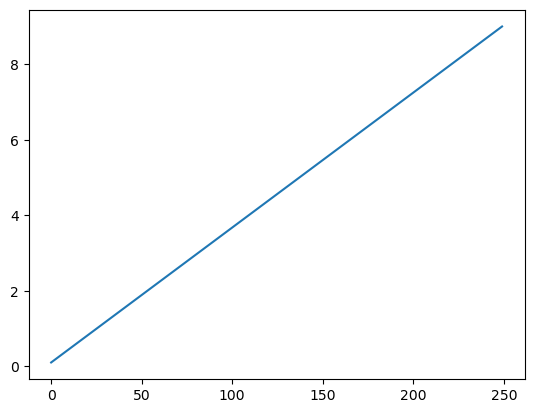

In [16]:
sns.lineplot(discriminator_penalty_weight)

In [17]:
mod = SignalingModel(net = sn_ppis,
                 X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                 y_out = tf_adata.to_df().copy(), 
                 expr = adata.to_df().copy(), 
                 covariates = tf_adata.obs.copy(),
                 categorical_covariate_keys = ['seurat_annotations'],
                 projection_amplitude_in = 1, 
                 projection_amplitude_out = projection_amplitude_out,
                 weight_label = weight_label, source_label = source_label, target_label = target_label,
                 bionet_params = bionet_params, 
                 dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)
mod = trainer.train_model(verbose = False)
io.write_pickled_object(trainer, os.path.join(data_path, 'test_pin1.pickle'))



In [ ]:
mod = SignalingModel(net = sn_ppis,
                 X_in = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1']),
                 y_out = tf_adata.to_df().copy(), 
                 expr = adata.to_df().copy(), 
                 covariates = tf_adata.obs.copy(),
                 categorical_covariate_keys = ['seurat_annotations'],
                 projection_amplitude_in = 100, 
                 projection_amplitude_out = projection_amplitude_out,
                 weight_label = weight_label, source_label = source_label, target_label = target_label,
                 bionet_params = bionet_params, 
                 dtype = torch.float32, device = device, seed = seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)
mod = trainer.train_model(verbose = False)
io.write_pickled_object(trainer, os.path.join(data_path, 'test_pin100.pickle'))